# 撮影条件と光源Hue値を用いたチェスボード位置推定誤差の予測

## 解析概要

- **データの種類**: HOEを用いたチェスボード撮影実験のCSV測定データ。5段階の画像解像度、5段階の撮影角度、測定位置、および2光源のHue値を用いる。
- **予測対象**: PnPによる位置推定の補正前誤差 `dx` と `dy`（mm）。補正後誤差は入力に含めない。
- **使用モデル**: Scikit-Learn の `ExtraTreesRegressor`（決定木アンサンブル回帰）。
- **評価方法**: 全測定点を固定シードで学習80%・テスト20%に分割し、MAE、RMSE、R²を算出する。
- **達成精度**: 固定シードのテストデータで、`dx` は MAE 0.068 mm・R² 0.974、`dy` は MAE 0.167 mm・R² 0.961。

本Notebookは研究用の元CSVを読み込むが、元データは変更しない。GitHub提出時は、出力を保存済みのこのNotebookを提出物とする。

## 1. ライブラリの読み込み

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42
DATA_ROOT = Path("output")

## 2. CSVから学習用テーブルを作成

In [2]:
SCALE_FACTORS = {
    "full": 1,
    "half": 2,
    "quarter": 4,
    "eighth": 8,
    "sixteenth": 16,
}

def read_grid(path: Path, value_name: str) -> pd.DataFrame:
    # 縦軸y・横軸xのCSVを (x_mm, y_mm, value) の縦長表へ変換する。
    grid = pd.read_csv(path, index_col=0)
    grid.index = pd.to_numeric(grid.index, errors="coerce")
    grid.columns = pd.to_numeric(grid.columns, errors="coerce")
    grid = grid.apply(pd.to_numeric, errors="coerce")
    grid.index.name = "y_mm"
    grid.columns.name = "x_mm"
    return grid.stack(future_stack=True).rename(value_name).reset_index()

records = []
required_files = {
    "dx_error_matrix.csv": "dx_mm",
    "dy_error_matrix.csv": "dy_mm",
    "light1.csv": "light1_hue",
    "light2.csv": "light2_hue",
}

for dx_path in sorted(DATA_ROOT.glob("*/angle_*/dx_error_matrix.csv")):
    condition_dir = dx_path.parent
    scale_name = condition_dir.parent.name
    angle_match = re.fullmatch(r"angle_(\d+)", condition_dir.name)
    if scale_name not in SCALE_FACTORS or angle_match is None:
        continue

    tables = []
    for filename, value_name in required_files.items():
        csv_path = condition_dir / filename
        if not csv_path.exists():
            break
        tables.append(read_grid(csv_path, value_name))
    else:
        merged = tables[0]
        for table in tables[1:]:
            merged = merged.merge(table, on=["x_mm", "y_mm"], how="inner")
        merged["angle_deg"] = int(angle_match.group(1))
        merged["downsample_factor"] = SCALE_FACTORS[scale_name]
        merged["resolution"] = scale_name
        records.append(merged)

if not records:
    raise FileNotFoundError("output/*/angle_*/ 以下に必要なCSVが見つかりません。")

data = pd.concat(records, ignore_index=True).dropna().reset_index(drop=True)
feature_columns = ["x_mm", "y_mm", "angle_deg", "downsample_factor", "light1_hue", "light2_hue"]
target_columns = ["dx_mm", "dy_mm"]

print(f"利用条件数: {data[['resolution', 'angle_deg']].drop_duplicates().shape[0]}")
print(f"有効測定点数: {len(data):,}")
display(data.head())
display(data.groupby(["resolution", "angle_deg"]).size().rename("n").unstack(0).fillna(0).astype(int))

利用条件数: 21
有効測定点数: 63,022


,y_mm,x_mm,dx_mm,dy_mm,light1_hue,light2_hue,angle_deg,downsample_factor,resolution
0,0.0,56.0,0.092056,-0.216584,15.743,35.586,0,8,eighth
1,0.0,57.0,0.045348,-0.182502,16.613,32.286,0,8,eighth
2,0.0,58.0,0.095094,0.026413,17.518,29.770,0,8,eighth
3,0.0,59.0,0.052189,0.005212,18.622,26.878,0,8,eighth
4,0.0,60.0,0.136486,-0.074742,19.835,24.347,0,8,eighth


resolution,eighth,full,half,quarter,sixteenth
angle_deg,,,,,
0,3027,3000,3007,3012,3051
5,3021,3007,3009,3014,0
10,3003,2994,3001,3017,0
15,2999,2968,2975,2993,0
20,3010,2966,2969,2979,0


## 3. 学習・テストデータへの分割

In [3]:
X = data[feature_columns]
y = data[target_columns]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"学習データ: {len(X_train):,} 点 / テストデータ: {len(X_test):,} 点")

学習データ: 50,417 点 / テストデータ: 12,605 点


## 4. ベースラインとExtra Trees回帰モデルの評価

In [4]:
def evaluate(name, estimator, X_eval, y_true):
    prediction = estimator.predict(X_eval)
    rows = []
    for index, target in enumerate(target_columns):
        actual = y_true[target].to_numpy()
        pred = prediction[:, index]
        rows.append({
            "model": name,
            "target": target,
            "MAE [mm]": mean_absolute_error(actual, pred),
            "RMSE [mm]": mean_squared_error(actual, pred) ** 0.5,
            "R2": r2_score(actual, pred),
        })
    return pd.DataFrame(rows), prediction

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

model = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train)

baseline_scores, _ = evaluate("平均値ベースライン", baseline, X_test, y_test)
model_scores, y_pred = evaluate("Extra Trees", model, X_test, y_test)
scores = pd.concat([baseline_scores, model_scores], ignore_index=True)
display(scores.round(4))

summary = model_scores.set_index("target")
print(
    "Extra Treesのテスト精度: "
    f"dx MAE={summary.loc['dx_mm', 'MAE [mm]']:.3f} mm, R²={summary.loc['dx_mm', 'R2']:.3f}; "
    f"dy MAE={summary.loc['dy_mm', 'MAE [mm]']:.3f} mm, R²={summary.loc['dy_mm', 'R2']:.3f}"
)

,model,target,MAE [mm],RMSE [mm],R2
0,平均値ベースライン,dx_mm,0.5327,0.6037,-0.0001
1,平均値ベースライン,dy_mm,1.1468,1.3728,-0.0003
2,Extra Trees,dx_mm,0.0684,0.0974,0.9740
3,Extra Trees,dy_mm,0.1675,0.2703,0.9612


Extra Treesのテスト精度: dx MAE=0.068 mm, R²=0.974; dy MAE=0.167 mm, R²=0.961


## 5. 可視化

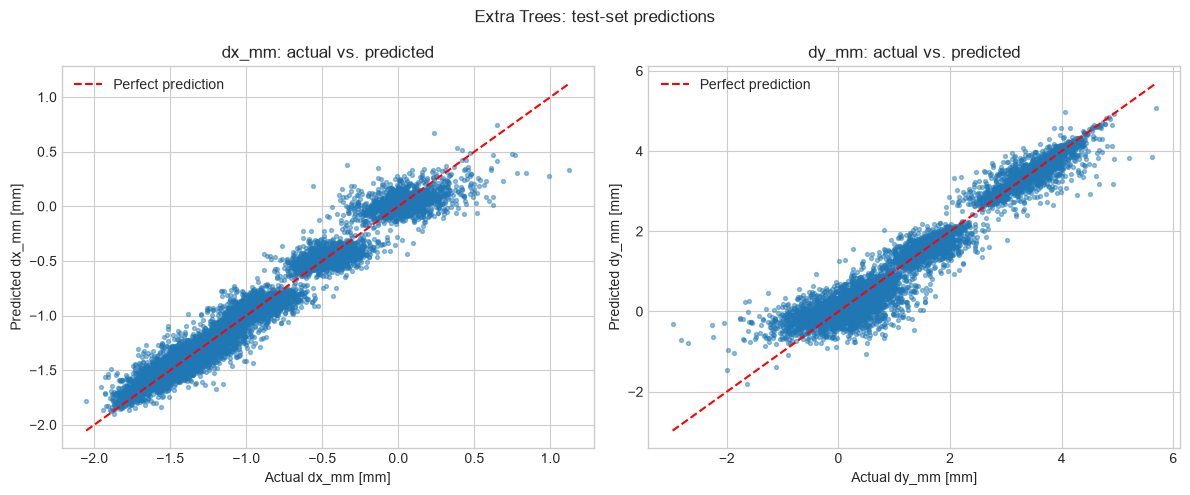

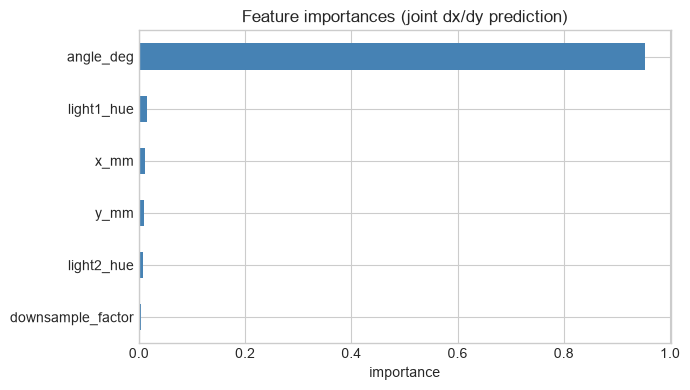

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target_index in zip(axes, range(2)):
    target = target_columns[target_index]
    actual = y_test[target].to_numpy()
    pred = y_pred[:, target_index]
    low = min(actual.min(), pred.min())
    high = max(actual.max(), pred.max())
    ax.scatter(actual, pred, s=8, alpha=0.45)
    ax.plot([low, high], [low, high], "r--", label="Perfect prediction")
    ax.set_xlabel(f"Actual {target} [mm]")
    ax.set_ylabel(f"Predicted {target} [mm]")
    ax.set_title(f"{target}: actual vs. predicted")
    ax.legend()
fig.suptitle("Extra Trees: test-set predictions")
plt.tight_layout()
plt.show()

importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values()
ax = importances.plot.barh(figsize=(7, 4), color="steelblue")
ax.set_title("Feature importances (joint dx/dy prediction)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 6. まとめ

位置・撮影角度・解像度・2光源のHue値から、補正前の位置推定誤差を回帰予測した。平均値だけを出すベースラインと比べ、Extra TreesのMAEとR²が改善していれば、測定条件に含まれる非線形な誤差傾向をモデルが捉えられたと解釈できる。

今回は課題用の簡潔な検証として、測定点をランダムに学習・テスト分割した。未知の撮影角度や新しい実験日への一般化を主張するには、角度または撮影日単位で丸ごと分ける追加検証が必要である。